### Exercise

At the same level as this notebook on github, there is an Exercise folder that contains carprices.csv. This file has car sell prices for 3 different models. First plot data points on a scatter plot chart to see if linear regression model can be applied. If yes, then build a model that can answer following questions,

-  Predict price of a Mercedez Benz that is 4 yr old with Mileage 45000

-  Predict price of a BMW X5 that is 7 yr old with Mileage 86000

-  Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())

In [30]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('carprices.csv')

In [32]:
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


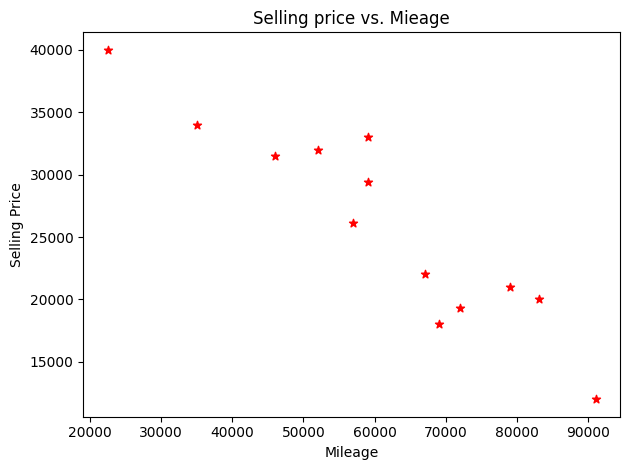

In [33]:
plt.scatter(df['Mileage'], df['Sell Price($)'], color='r', marker='*')
plt.title('Selling price vs. Mieage')
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.tight_layout()

In [34]:
dummies = pd.get_dummies(df['Car Model']).astype(int)
dummies

,Audi A5,BMW X5,Mercedez Benz C class
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


In [35]:
df_final = pd.concat([df.drop(['Car Model'], axis='columns'), dummies.drop(['Audi A5'], axis='columns')], axis='columns')

In [36]:
df_final

,Mileage,Sell Price($),Age(yrs),BMW X5,Mercedez Benz C class
0,69000,18000,6,1,0
1,35000,34000,3,1,0
2,57000,26100,5,1,0
3,22500,40000,2,1,0
4,46000,31500,4,1,0
5,59000,29400,5,0,0
6,52000,32000,5,0,0
7,72000,19300,6,0,0
8,91000,12000,8,0,0
9,67000,22000,6,0,1


In [37]:
model = LinearRegression()

In [38]:
X, y = df_final[['Mileage', 'Age(yrs)', 'BMW X5', 'Mercedez Benz C class']], df_final['Sell Price($)']

In [39]:
model.fit(X, y)

LinearRegression()

In [40]:
model.predict([[45000, 4, 0, 1]])

C:\Users\rajoh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36991.31721061])

In [41]:
model.predict([[86000, 7, 1, 0]])

C:\Users\rajoh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11080.74313219])

In [42]:
model.score(X, y)

0.9417050937281082